# 03 Multivariate Analysis

Analyses the structure of the driver-season dataset using correlation 
analysis, Principal Component Analysis (PCA), and K-Means clustering.
The goal is to understand which features are most important, how they 
relate to each other, and whether natural performance groupings exist 
in the data.

**Input:** `data/processed/driver_season_summary.csv`  
**Output:** `data/processed/driver_season_clustered.csv`, plots in `outputs/`

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from pathlib import Path

In [20]:
PROCESSED_DIR = Path('../data/processed')
OUTPUT_DIR    = Path('../outputs')
OUTPUT_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED_DIR / 'driver_season_summary.csv')

print("Shape:", df.shape)
print("\nFeature columns:")
print(df.select_dtypes(include='number').columns.tolist())

Shape: (105, 17)

Feature columns:
['season', 'races', 'total_points', 'points_per_race', 'avg_finish_position', 'finish_position_std', 'wins', 'podiums', 'dnfs', 'dnf_rate', 'avg_positions_gained', 'points_finish_rate', 'avg_quali_position']


## Correlation Analysis

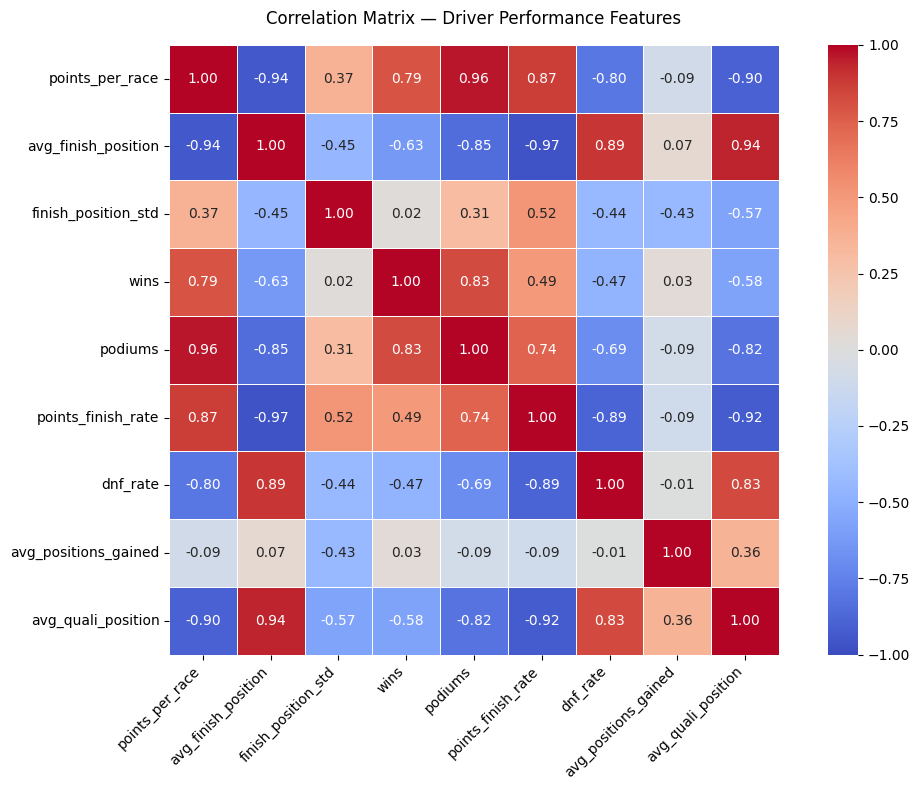

In [21]:
feature_cols = [
    'points_per_race',
    'avg_finish_position',
    'finish_position_std',
    'wins',
    'podiums',
    'points_finish_rate',
    'dnf_rate',
    'avg_positions_gained',
    'avg_quali_position'
]

corr = df[feature_cols].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Correlation Matrix — Driver Performance Features', pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'correlation_heatmap.png', dpi=150)
plt.show()

## Principal Component Analysis (PCA)

In [22]:
X = df[feature_cols]

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

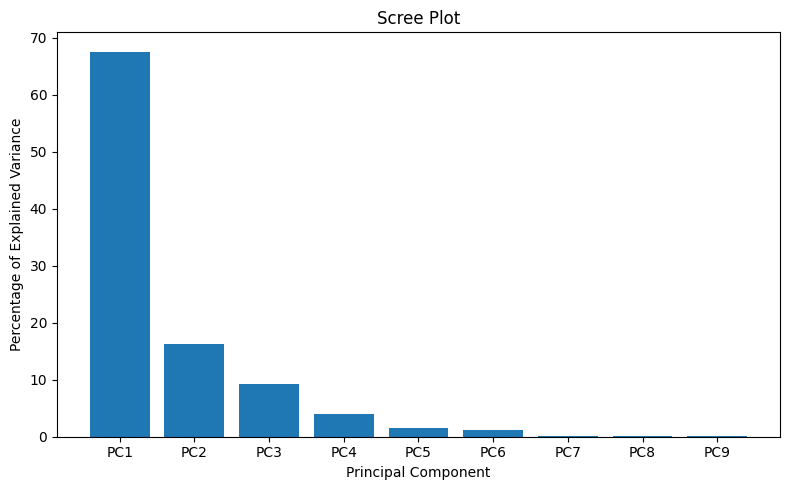

Variance explained per component:
  PC1: 67.6%  (cumulative: 67.6%)
  PC2: 16.2%  (cumulative: 83.8%)
  PC3: 9.2%  (cumulative: 93.0%)
  PC4: 4.0%  (cumulative: 97.0%)
  PC5: 1.5%  (cumulative: 98.5%)
  PC6: 1.1%  (cumulative: 99.6%)
  PC7: 0.2%  (cumulative: 99.8%)
  PC8: 0.1%  (cumulative: 99.9%)
  PC9: 0.1%  (cumulative: 100.0%)


In [23]:
pca     = PCA()
X_pca   = pca.fit_transform(X_scaled)
per_var = np.round(pca.explained_variance_ratio_ * 100, decimals=1)
labels  = ['PC' + str(i) for i in range(1, len(per_var) + 1)]

plt.figure(figsize=(8, 5))
plt.bar(x=range(1, len(per_var) + 1), height=per_var, tick_label=labels)
plt.ylabel('Percentage of Explained Variance')
plt.xlabel('Principal Component')
plt.title('Scree Plot')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'scree_plot.png', dpi=150)
plt.show()

print("Variance explained per component:")
cumulative = 0
for label, var in zip(labels, per_var):
    cumulative += var
    print(f"  {label}: {var}%  (cumulative: {cumulative:.1f}%)")

### Interpretation

PC1 captures 67.6% of the total variance in the dataset meaning that a 
single underlying dimension explains the majority of differences between 
driver-season performances. PC1 and PC2 together explain 83.8%, which means 
two components capture most of what is happening across all nine features.

The clear elbow after PC2 in the scree plot confirms that additional components 
add very little explanatory value. This level of concentration in PC1 is a direct 
consequence of the high correlations seen in the heatmap points_per_race, 
podiums, avg_finish_position and avg_quali_position are all measuring variations 
of the same underlying concept: how competitive a driver was that season. PCA 
has collapsed that redundancy into a single dominant component.

PC2 capturing 16.2% likely represents a secondary dimension, something that 
varies independently of overall competitiveness. The PC1 loading scores in the 
next cell will show exactly which features drive each component.

## PC1 Loading Scores


PC1 loading scores (sorted by absolute value):
avg_finish_position     0.396
points_per_race         0.395
avg_quali_position      0.390
points_finish_rate      0.380
podiums                 0.368
dnf_rate                0.356
wins                    0.285
finish_position_std     0.205
avg_positions_gained    0.069
dtype: float64


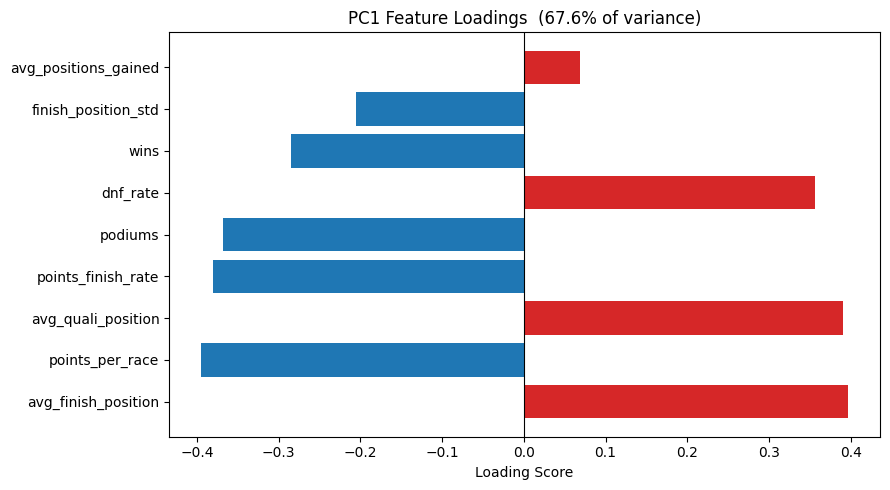

In [24]:
loading_scores = pd.Series(pca.components_[0], index=feature_cols)
loading_scores_sorted = loading_scores.abs().sort_values(ascending=False)

print("PC1 loading scores (sorted by absolute value):")
print(loading_scores_sorted.round(3))

colors = ['#d62728' if loading_scores[f] > 0 else '#1f77b4'
          for f in loading_scores_sorted.index]

plt.figure(figsize=(9, 5))
plt.barh(loading_scores_sorted.index,
         loading_scores[loading_scores_sorted.index],
         color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title(f'PC1 Feature Loadings  ({per_var[0]}% of variance)')
plt.xlabel('Loading Score')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pc1_loadings.png', dpi=150)
plt.show()